In [3]:
import os
import pandas as pd
import re

In [4]:
PROMPT_STATS_DIR = r"..\2_prompts_cossim\prompts_sim_stats"
RESPONSE_STATS_DIR = r"..\3_responses_cossim\response_cossim_stats"
OUTPUT_FILE = "prompt_vs_response.csv"

In [5]:
PROVIDERS = {
    "mistralai": "Mistral-7B-Instruct-v0.2",
    "meta-llama": "Meta-Llama-3-8B-Instruct",
    "microsoft": "Phi-3-mini-4k-instruct"
}
BITS = ["4bit", "8bit", "fp16"]

CATEGORIES = ["qna", "reasoning", "logical", "classification"]

In [6]:
def generate_comparison_csv():
    all_rows = []

    print("Gathering data for comparison...")
    
    for category in CATEGORIES:
        prompt_file = f"{category}_prompt_similarity_stats.csv"
        prompt_path = os.path.join(PROMPT_STATS_DIR, prompt_file)
        
        if not os.path.exists(prompt_path):
            continue
            
        prompt_df = pd.read_csv(prompt_path)
        
        # Load all Response Stats for this category
        response_data = {}
        for provider, model_base in PROVIDERS.items():
            for bit in BITS:
                model_bit = f"{model_base}_{bit}"
                resp_file = f"{category}_response_cossim_stats.csv"
                resp_path = os.path.join(RESPONSE_STATS_DIR, provider, model_bit, resp_file)
                if os.path.exists(resp_path):
                    response_data[model_bit] = pd.read_csv(resp_path)
        
        # Find variant columns (e.g., qna_1_V1)
        variant_cols = [c for c in prompt_df.columns if re.search(r'_\d+_V\d+', c)]
        
        for _, drift_row in prompt_df.iterrows():
            drift_level = int(drift_row["Drift/Variant"])
            
            for col in variant_cols:
                prompt_sim = drift_row[col]
                
                # Extract numeric ID and variant for clean labeling
                prompt_id_match = re.search(r'(\d+)_V(\d+)', col)
                num = prompt_id_match.group(1) if prompt_id_match else "N/A"
                var = prompt_id_match.group(2) if prompt_id_match else "N/A"
                
                # Create the entry for this specific prompt-drift-variant
                entry = {
                    "Category": category,
                    "Drift_Level": drift_level,
                    "Prompt_ID": f"{category}_L{drift_level}_v{var}",
                    "Base_Prompt_Num": num,
                    "Variant_Num": var,
                    "Prompt_CosSim": round(prompt_sim, 2)
                }
                
                # Add response similarity for every available model/bit
                for model_key, resp_df in response_data.items():
                    # Match drift level in response stats
                    drift_col = resp_df.columns[0]
                    resp_row = resp_df[resp_df[drift_col] == drift_level]
                    
                    if not resp_row.empty and col in resp_df.columns:
                        entry[f"{model_key}_Resp_CosSim"] = round(resp_row[col].values[0], 2)
                    else:
                        entry[f"{model_key}_Resp_CosSim"] = None

                all_rows.append(entry)

    # Convert list to DataFrame and save
    if all_rows:
        final_df = pd.DataFrame(all_rows)
        final_df.to_csv(OUTPUT_FILE, index=False)
        print(f"Success! Comparison data saved to: {OUTPUT_FILE}")
    else:
        print("No data found to save.")

In [7]:
generate_comparison_csv()

Gathering data for comparison...
Success! Comparison data saved to: prompt_vs_response.csv


In [8]:
OUTPUT_FILE2 = "prompt_vs_response_with_with_mean.csv"

def generate_comparison_csv2():
    all_rows = []

    print("Gathering data and calculating means...")
    
    for category in CATEGORIES:
        prompt_file = f"{category}_prompt_similarity_stats.csv"
        prompt_path = os.path.join(PROMPT_STATS_DIR, prompt_file)
        
        if not os.path.exists(prompt_path):
            continue
            
        prompt_df = pd.read_csv(prompt_path)
        
        # Load all Response Stats for this category
        response_data = {}
        for provider, model_base in PROVIDERS.items():
            for bit in BITS:
                model_bit = f"{model_base}_{bit}"
                resp_file = f"{category}_response_cossim_stats.csv"
                resp_path = os.path.join(RESPONSE_STATS_DIR, provider, model_bit, resp_file)
                if os.path.exists(resp_path):
                    response_data[model_bit] = pd.read_csv(resp_path)
        
        # Find variant columns (e.g., qna_1_V1)
        variant_cols = [c for c in prompt_df.columns if re.search(r'_\d+_V\d+', c)]
        
        for _, drift_row in prompt_df.iterrows():
            drift_level = int(drift_row["Drift/Variant"])
            
            for col in variant_cols:
                prompt_sim = drift_row[col]
                
                # Extract base prompt number (e.g., '1' from 'qna_1_V1')
                prompt_id_match = re.search(r'(\d+)_V(\d+)', col)
                num = prompt_id_match.group(1) if prompt_id_match else "N/A"
                var = prompt_id_match.group(2) if prompt_id_match else "N/A"
                
                # Create the entry for this specific prompt-drift-variant
                entry = {
                    "Category": category,
                    "Drift_Level": drift_level,
                    "Prompt_ID": f"{category}_L{drift_level}_v{var}",
                    "Base_Prompt_Num": num,
                    "Variant_Num": var,
                    "Prompt_CosSim": round(prompt_sim, 2),
                    # 1. Mean for this specific base prompt across its variants (from prompt stats)
                    "Prompt_Group_Mean": round(drift_row.get(f"{category}_{num}_mean", 0), 2),
                    # 2. Overall category mean for this drift level (from prompt stats)
                    "Prompt_Overall_Drift_Mean": round(drift_row.get("overall_mean", 0), 2)
                }
                
                # Add response metrics for every available model/bit
                for model_key, resp_df in response_data.items():
                    drift_col = resp_df.columns[0]
                    resp_row = resp_df[resp_df[drift_col] == drift_level]
                    
                    if not resp_row.empty:
                        # 3. Specific response similarity for this variant
                        if col in resp_df.columns:
                            entry[f"{model_key}_Resp_CosSim"] = round(resp_row[col].values[0], 2)
                        
                        # 4. Mean for this prompt group in this model
                        group_mean_col = f"{category}_{num}_mean"
                        if group_mean_col in resp_df.columns:
                            entry[f"{model_key}_Resp_Group_Mean"] = round(resp_row[group_mean_col].values[0], 2)
                            
                        # 5. Overall model mean similarity for this drift level
                        if "overall_mean" in resp_df.columns:
                            entry[f"{model_key}_Resp_Overall_Drift_Mean"] = round(resp_row["overall_mean"].values[0], 2)
                    else:
                        entry[f"{model_key}_Resp_CosSim"] = None
                        entry[f"{model_key}_Resp_Group_Mean"] = None
                        entry[f"{model_key}_Resp_Overall_Drift_Mean"] = None

                all_rows.append(entry)

    # Convert list to DataFrame and save
    if all_rows:
        final_df = pd.DataFrame(all_rows)
        final_df.to_csv(OUTPUT_FILE2, index=False)
        print(f"Success! Comprehensive comparison saved to: {OUTPUT_FILE2}")
    else:
        print("No data found to save.")

In [9]:
generate_comparison_csv2()

Gathering data and calculating means...
Success! Comprehensive comparison saved to: prompt_vs_response_with_with_mean.csv


# Visualization


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
sns.set(style="whitegrid")
%matplotlib inline

In [12]:
def visualize_prompt_vs_response(comparison_csv):
    """
    Visualizes the relationship between Prompt Drift and Model Response Drift
    with dynamic Y-axis scaling for better resolution.
    """
    if not os.path.exists(comparison_csv):
        print(f"Error: {comparison_csv} not found.")
        return

    df = pd.read_csv(comparison_csv)
    
    # Identify the response columns
    resp_cols = [c for c in df.columns if c.endswith("_Resp_CosSim")]
    models = sorted(list(set([c.replace("_Resp_CosSim", "") for c in resp_cols])))
    
    # ------------------------------------------------------------------
    # 1. SCATTER PLOTS: Prompt Similarity vs. Response Similarity
    # ------------------------------------------------------------------
    print("Generating Correlation Scatter Plots...")
    
    n_models = len(models)
    cols = 3
    rows = (n_models + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten()

    for i, model in enumerate(models):
        y_col = f"{model}_Resp_CosSim"
        valid_df = df.dropna(subset=[y_col, "Prompt_CosSim"])
        
        if not valid_df.empty:
            sns.regplot(
                x="Prompt_CosSim", 
                y=y_col, 
                data=valid_df, 
                ax=axes[i],
                scatter_kws={'alpha':0.5, 's':20},
                line_kws={'color':'red', 'lw':2}
            )
            
            corr = valid_df["Prompt_CosSim"].corr(valid_df[y_col])
            
            # Dynamic Y-Axis scaling
            # Find the floor (min value - 5, rounded down to nearest 5 or 10)
            local_min = min(valid_df["Prompt_CosSim"].min(), valid_df[y_col].min())
            y_floor = max(0, (local_min // 5) * 5 - 5) 

            axes[i].set_title(f"{model}\nCorrelation: {corr:.2f}")
            axes[i].set_xlabel("Prompt CosSim (%)")
            axes[i].set_ylabel("Response CosSim (%)")
            axes[i].set_xlim(y_floor, 105)
            axes[i].set_ylim(y_floor, 105)
        else:
            axes[i].set_title(f"{model} (No Data)")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------
    # 2. LINE PLOT: Average Decay (Prompt Mean vs. Model Mean)
    # ------------------------------------------------------------------
    print("\nGenerating Performance Decay Curves with Adjusted Y-Axis...")
    
    categories = df["Category"].unique()
    
    for cat in categories:
        cat_df = df[df["Category"] == cat]
        summary = cat_df.groupby("Drift_Level").mean(numeric_only=True)
        
        plt.figure(figsize=(12, 6))
        
        # Determine global minimum for this specific category to set the Y-axis
        # We check all mean columns + the prompt mean
        cols_to_check = [f"{m}_Resp_Overall_Drift_Mean" for m in models] + ["Prompt_Overall_Drift_Mean"]
        # Filter only existing columns
        existing_cols = [c for c in cols_to_check if c in summary.columns]
        global_min = summary[existing_cols].min().min()
        y_limit_bottom = max(0, (global_min // 5) * 5 - 5)

        # Plot Prompt Drift
        plt.plot(summary.index, summary["Prompt_Overall_Drift_Mean"], 
                 label="PROMPT (Input Drift)", color="black", linestyle="--", marker="X", linewidth=3)
        
        # Plot Model Responses
        for model in models:
            mean_col = f"{model}_Resp_Overall_Drift_Mean"
            if mean_col in summary.columns:
                plt.plot(summary.index, summary[mean_col], label=f"{model}", marker="o")
        
        plt.title(f"{cat.upper()} - Prompt Drift vs. Model Response Stability")
        plt.xlabel("Drift Level (L1 to L5)")
        plt.ylabel("Mean Cosine Similarity (%)")
        plt.xticks([1, 2, 3, 4, 5])
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        
        # Apply dynamic limit
        plt.ylim(y_limit_bottom, 105)
        
        plt.tight_layout()
        plt.show()

Generating Correlation Scatter Plots...


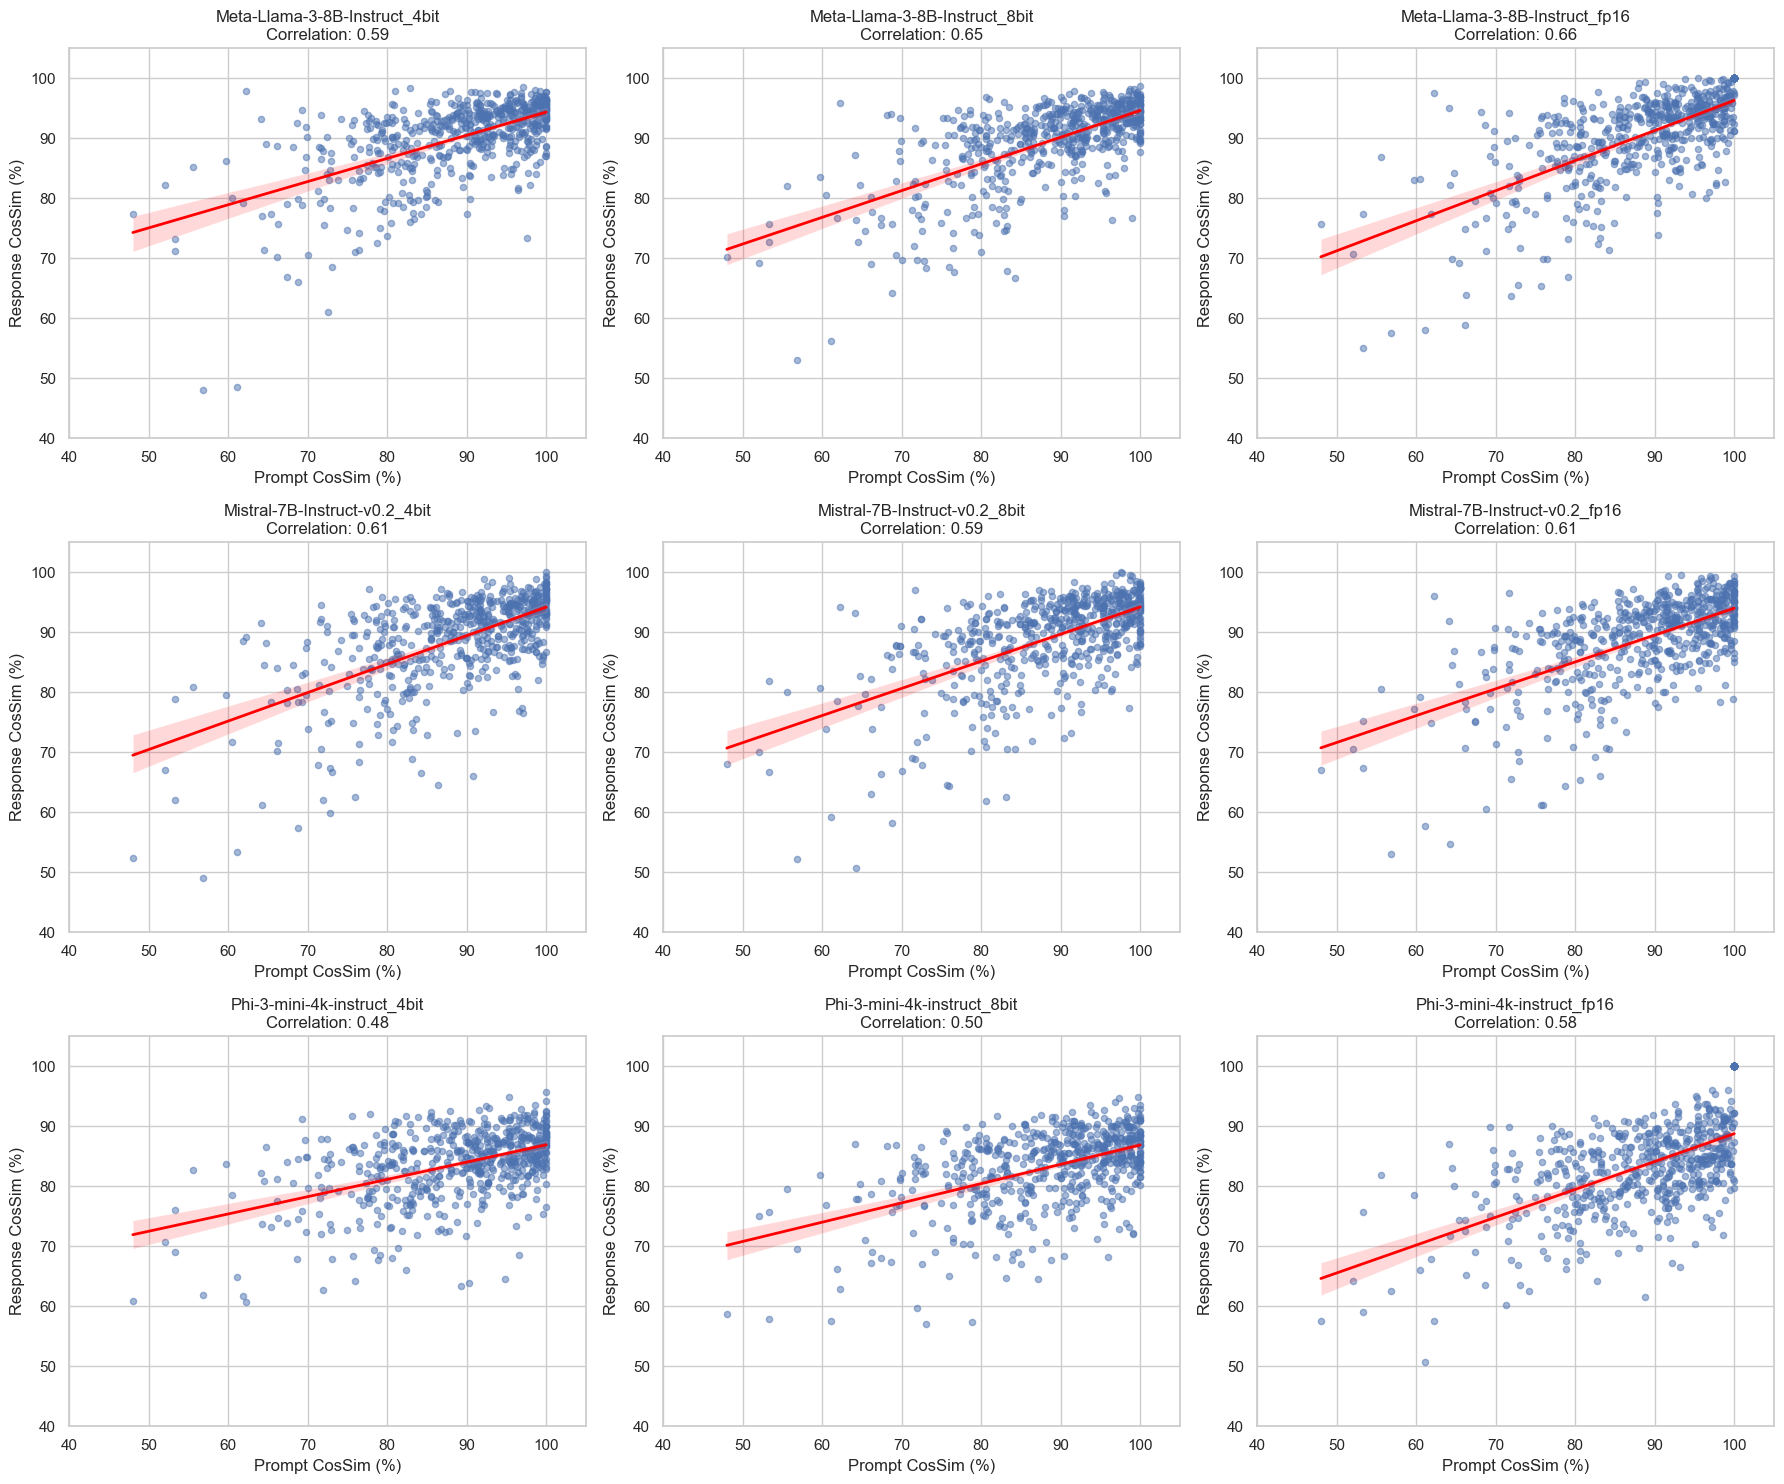


Generating Performance Decay Curves with Adjusted Y-Axis...


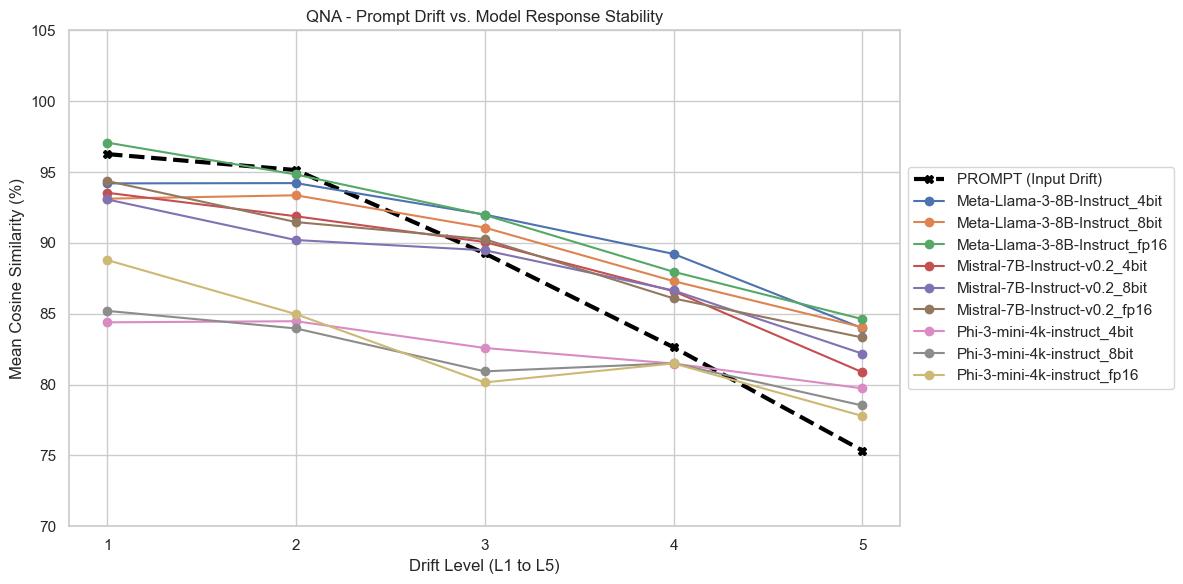

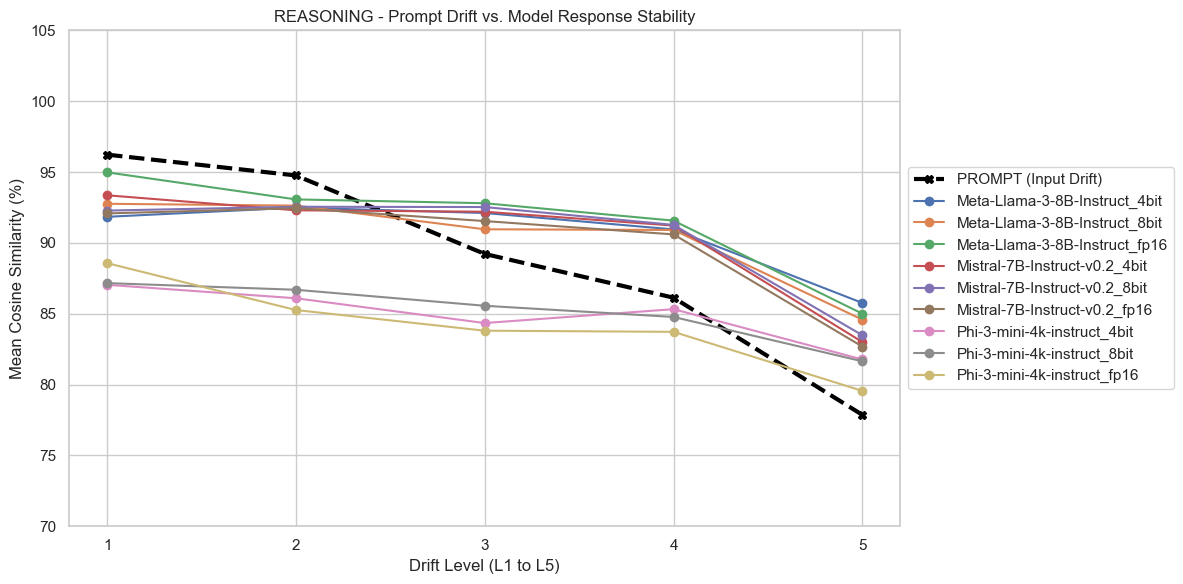

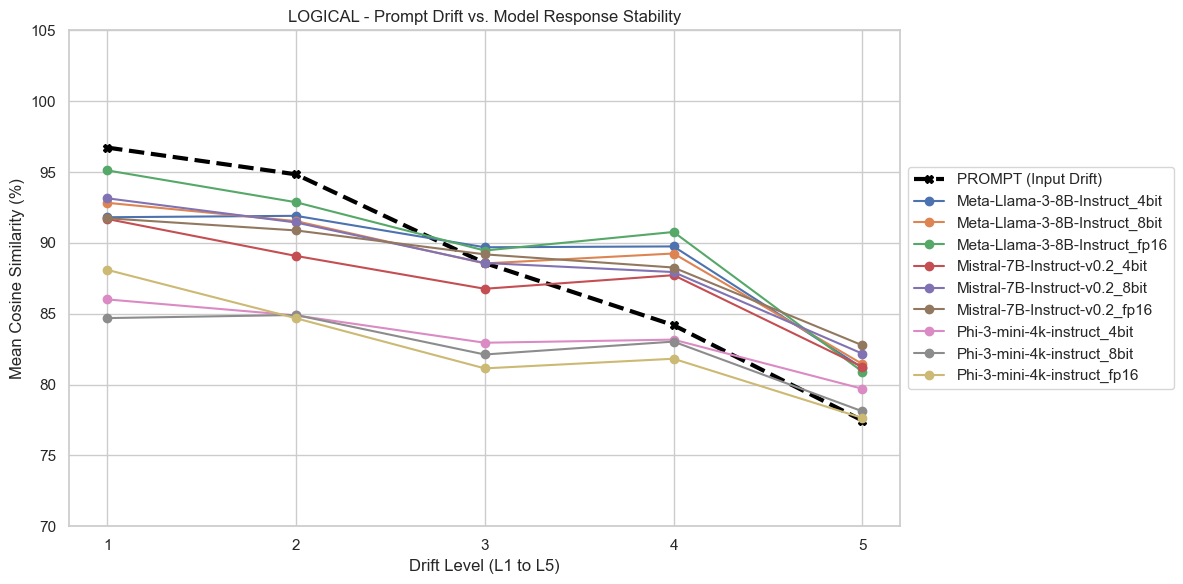

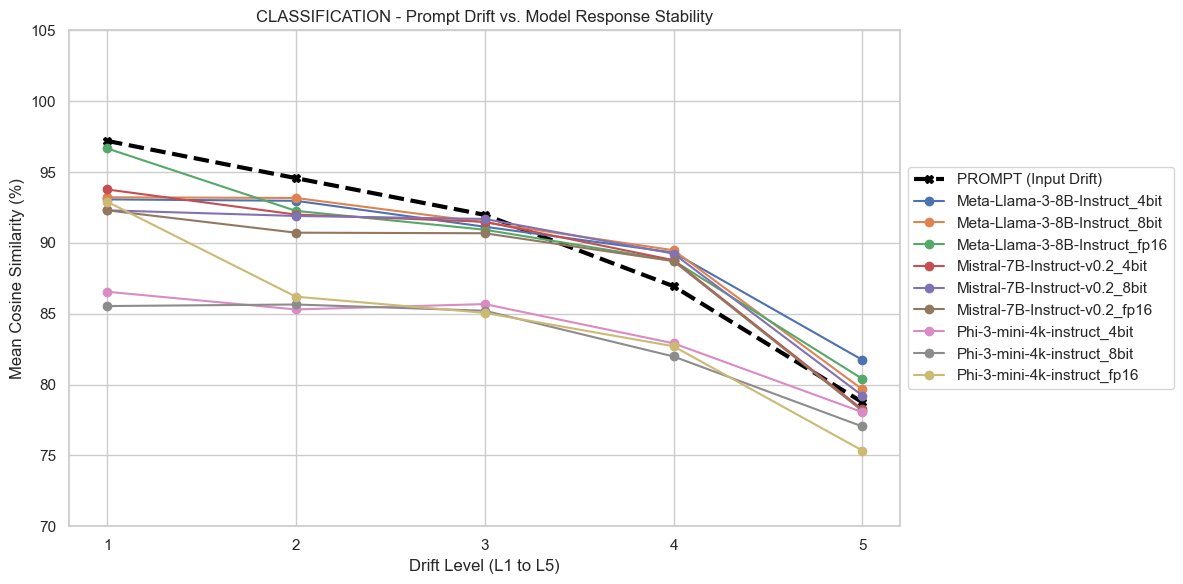

In [13]:
visualize_prompt_vs_response(OUTPUT_FILE2)

In [14]:
def visualize_grid_scatter(comparison_csv):

    df = pd.read_csv(comparison_csv)

    resp_cols = [c for c in df.columns if c.endswith("_Resp_CosSim")]
    model_quants = sorted(list(set([c.replace("_Resp_CosSim", "") for c in resp_cols])))

    categories = sorted(df["Category"].unique())

    for model_quant in model_quants:

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()

        for i, cat in enumerate(categories):

            ax = axes[i]
            cat_df = df[df["Category"] == cat]

            y_col = f"{model_quant}_Resp_CosSim"

            if y_col not in cat_df.columns:
                ax.set_title(f"{cat} (No Data)")
                continue

            valid_df = cat_df.dropna(subset=["Prompt_CosSim", y_col])

            if valid_df.empty:
                ax.set_title(f"{cat} (No Data)")
                continue

            # regression line (single overall)
            palette = {
                1: "#1976D2",  # Strong Blue (More saturated)
                2: "#2E7D32",  # Forest Green (Darker, won't wash out)
                3: "#D35400",  # Burnt Orange (Replaces the light orange for high contrast)
                4: "#C0392B",  # Deep Red (Crisp and distinct)
                5: "#641E16"   # Burgundy/Dark Red (Rich and dark)
            }

            sns.scatterplot(
                x="Prompt_CosSim",
                y=y_col,
                hue="Drift_Level",
                palette=palette,   # or "coolwarm", "plasma"
                data=valid_df,
                ax=ax,
                alpha=0.7,
                s=40
            )

            # regression line (single overall)
            sns.regplot(
                x="Prompt_CosSim",
                y=y_col,
                data=valid_df,
                scatter=False,
                ax=ax,
                line_kws={'color':'black', 'lw':2}
            )

            corr = valid_df["Prompt_CosSim"].corr(valid_df[y_col])

            local_min = min(valid_df["Prompt_CosSim"].min(), valid_df[y_col].min())
            y_floor = max(0, (local_min // 5) * 5 - 5)

            ax.set_title(f"{cat.upper()} | Corr: {corr:.2f}")
            ax.set_xlabel("Prompt CosSim")
            ax.set_ylabel("Response CosSim")
            ax.set_xlim(y_floor, 105)
            ax.set_ylim(y_floor, 105)

        plt.suptitle(f"Prompt vs Response Drift | {model_quant}", fontsize=16)
        plt.tight_layout()
        plt.show()

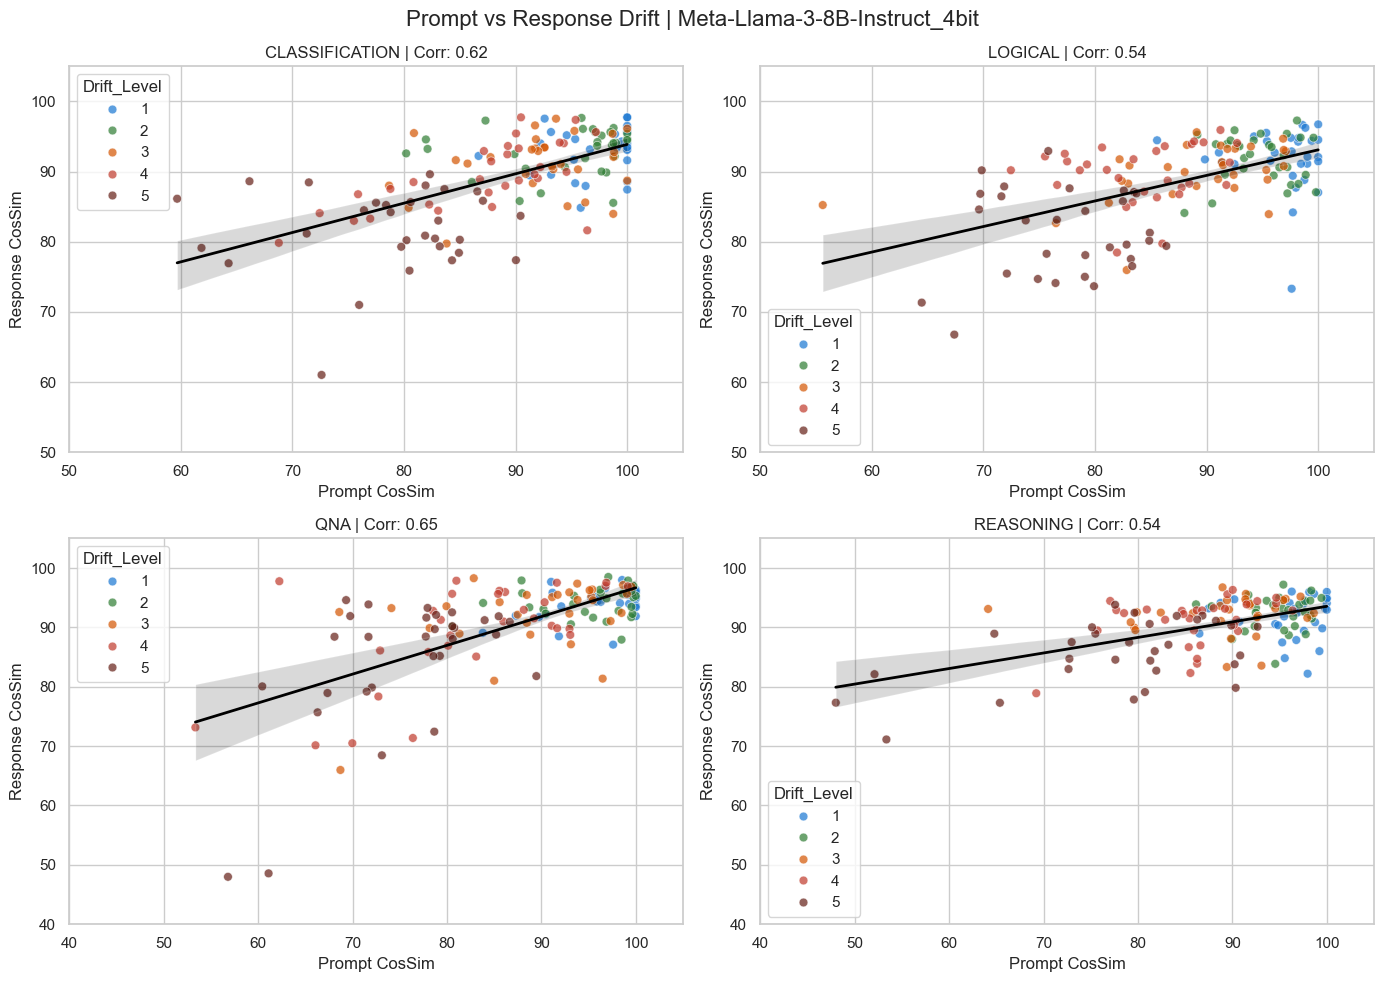

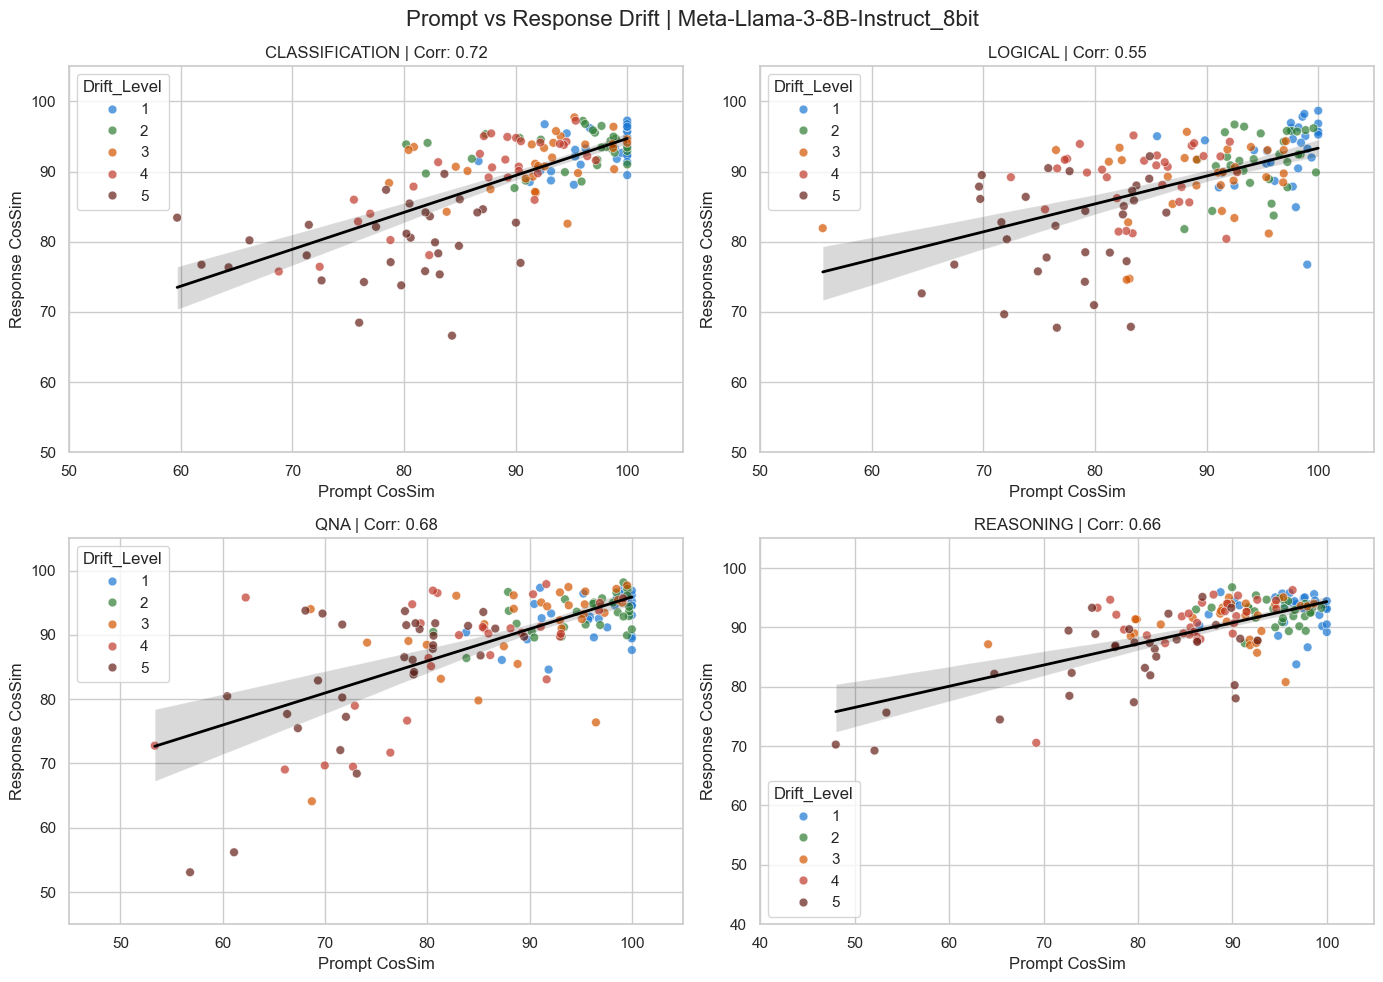

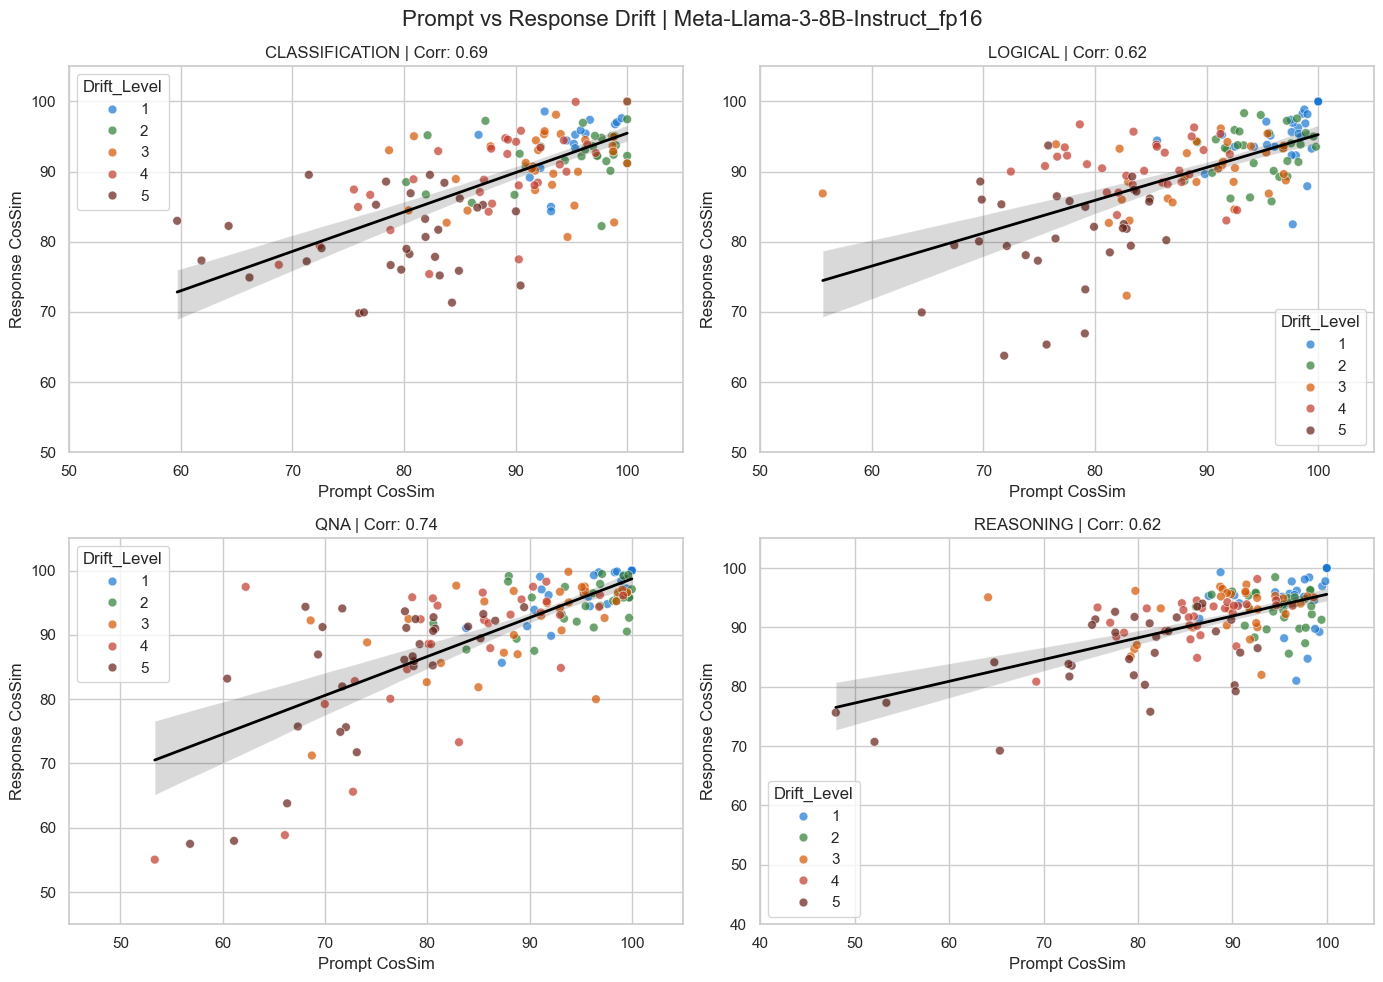

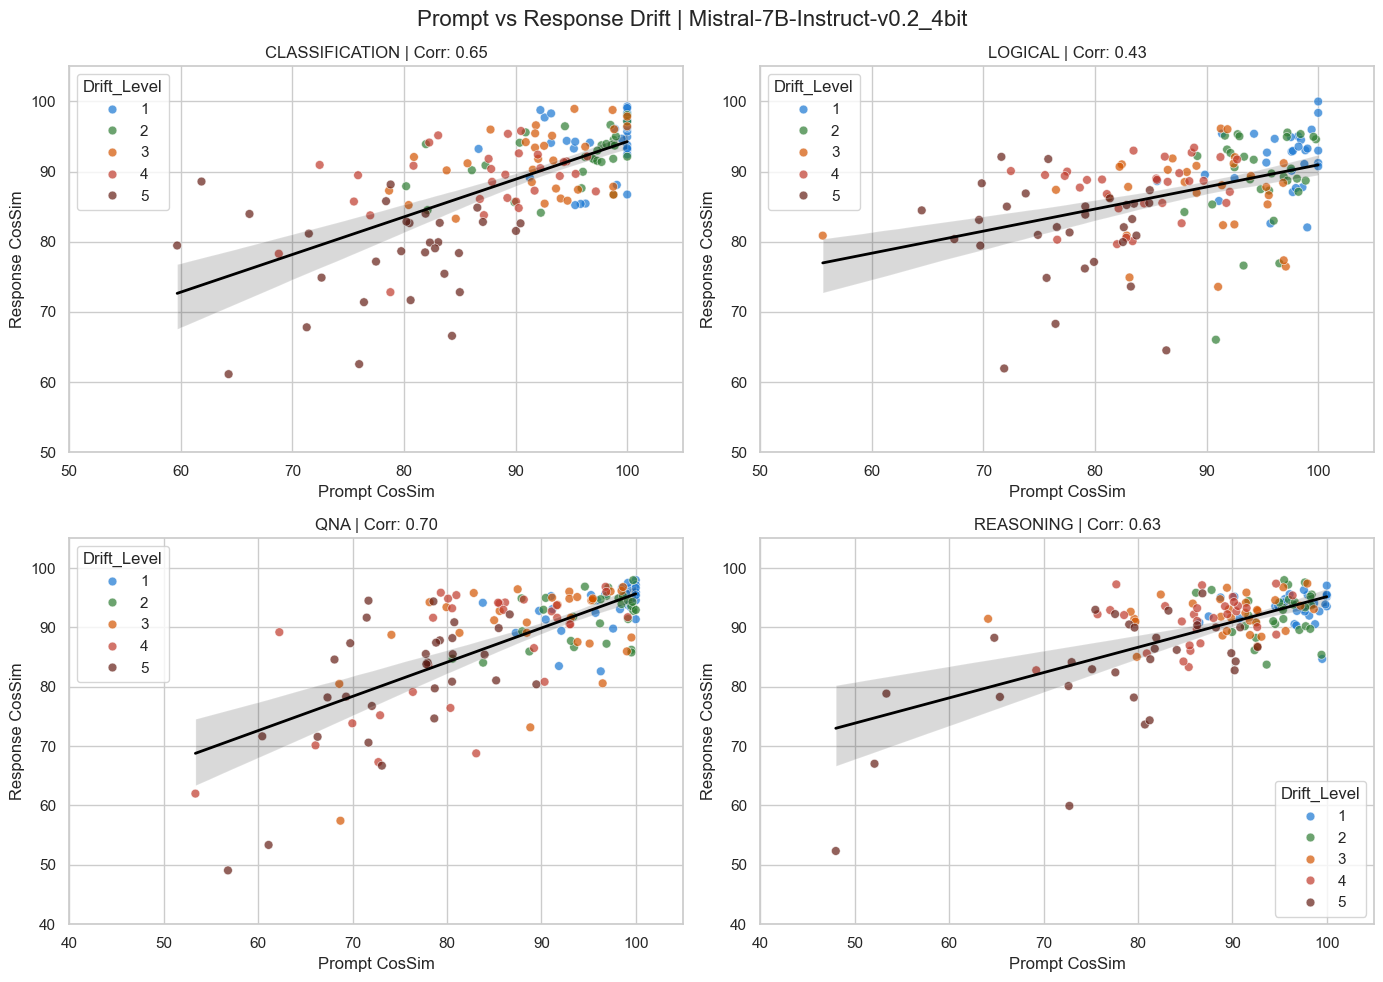

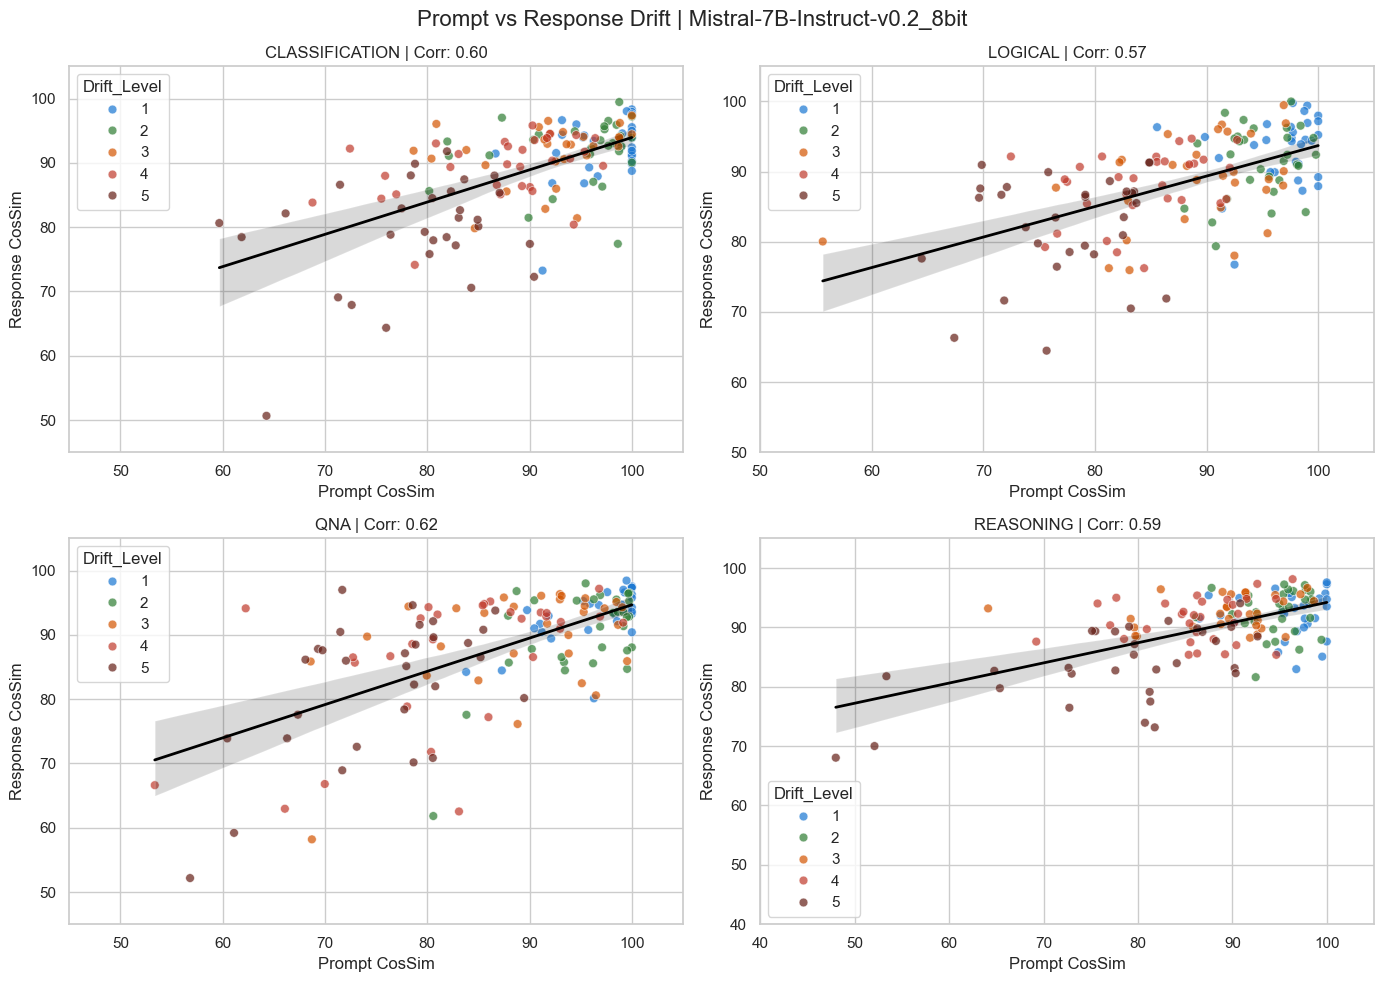

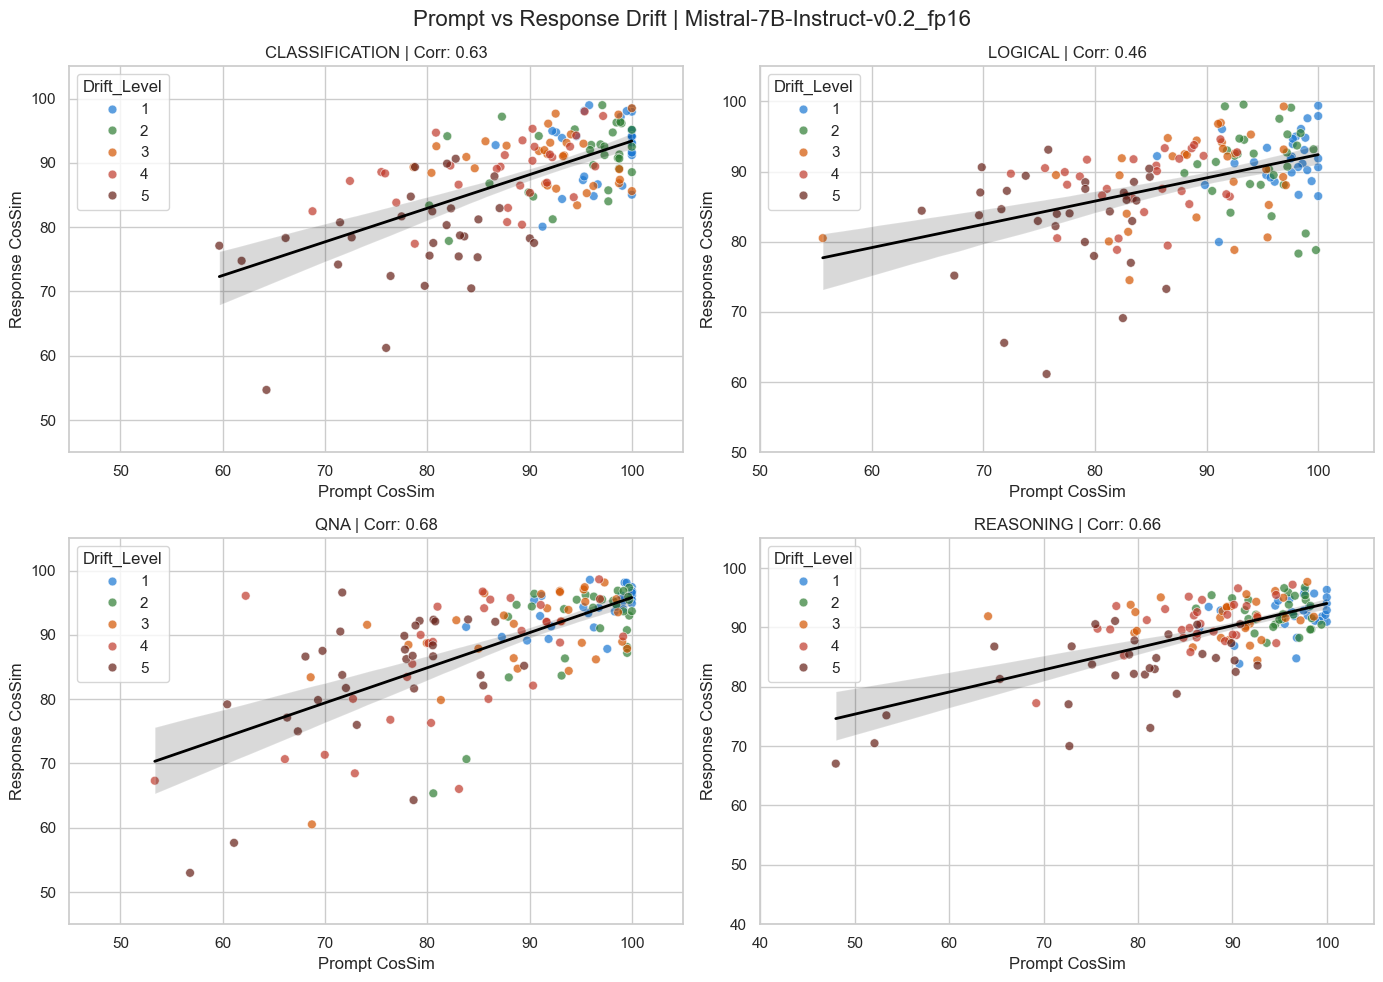

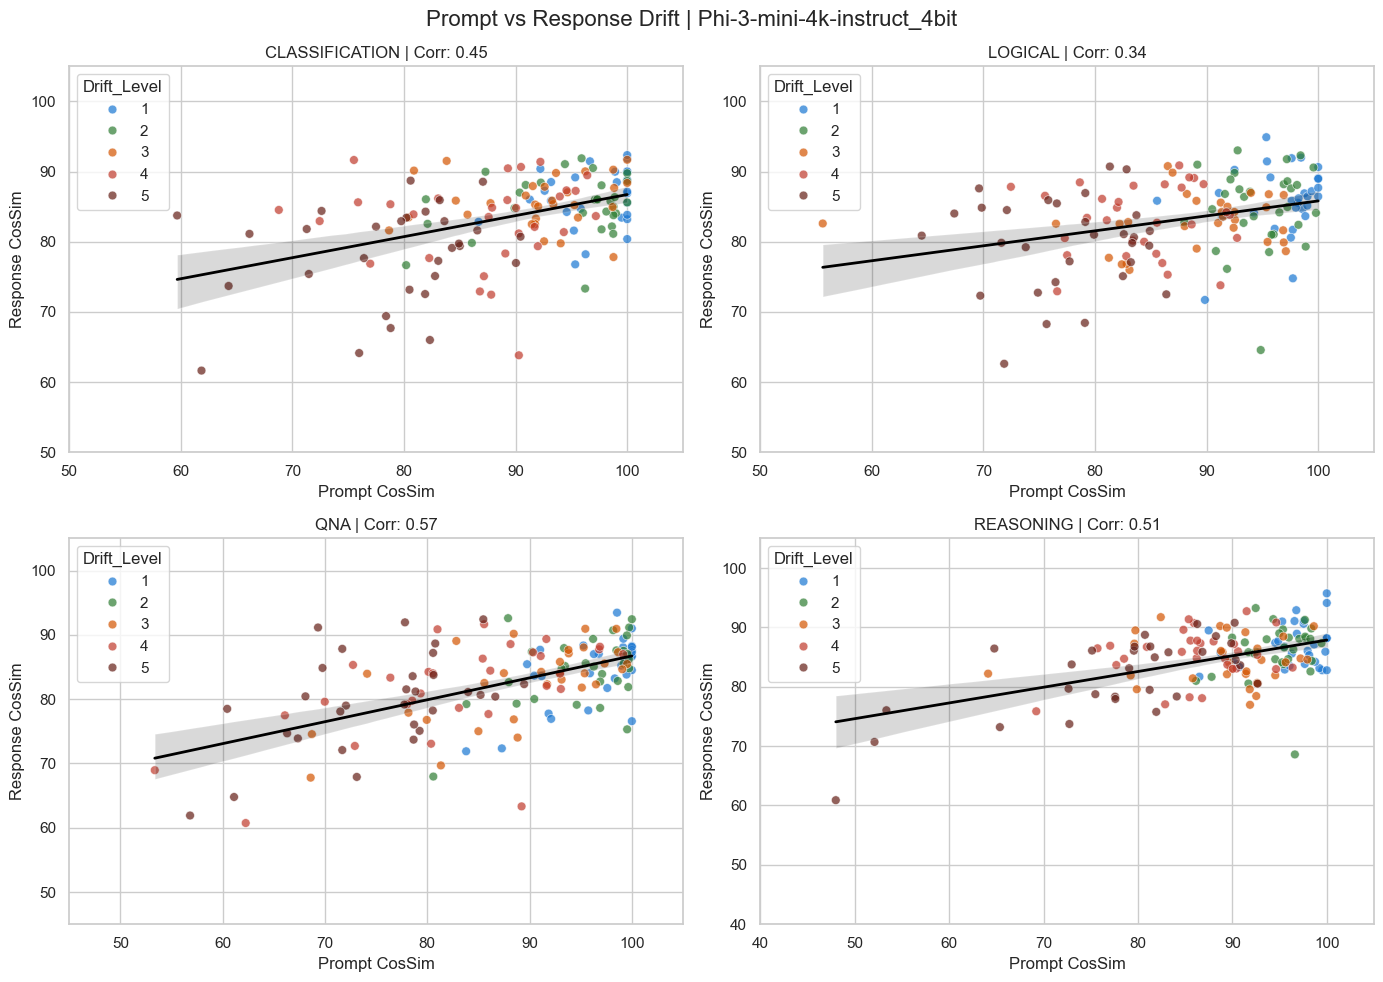

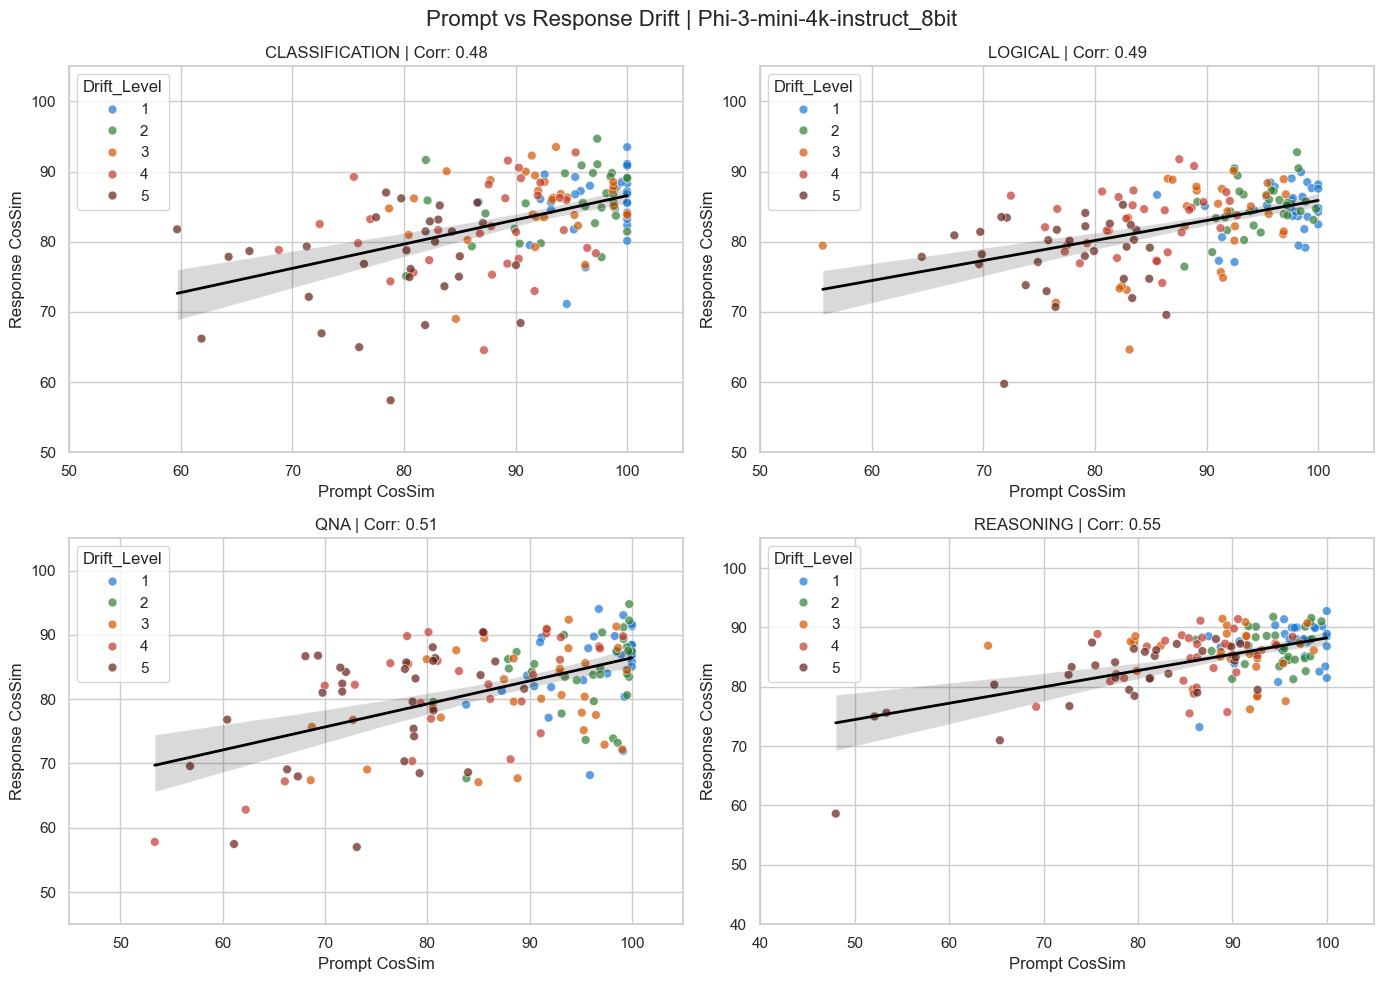

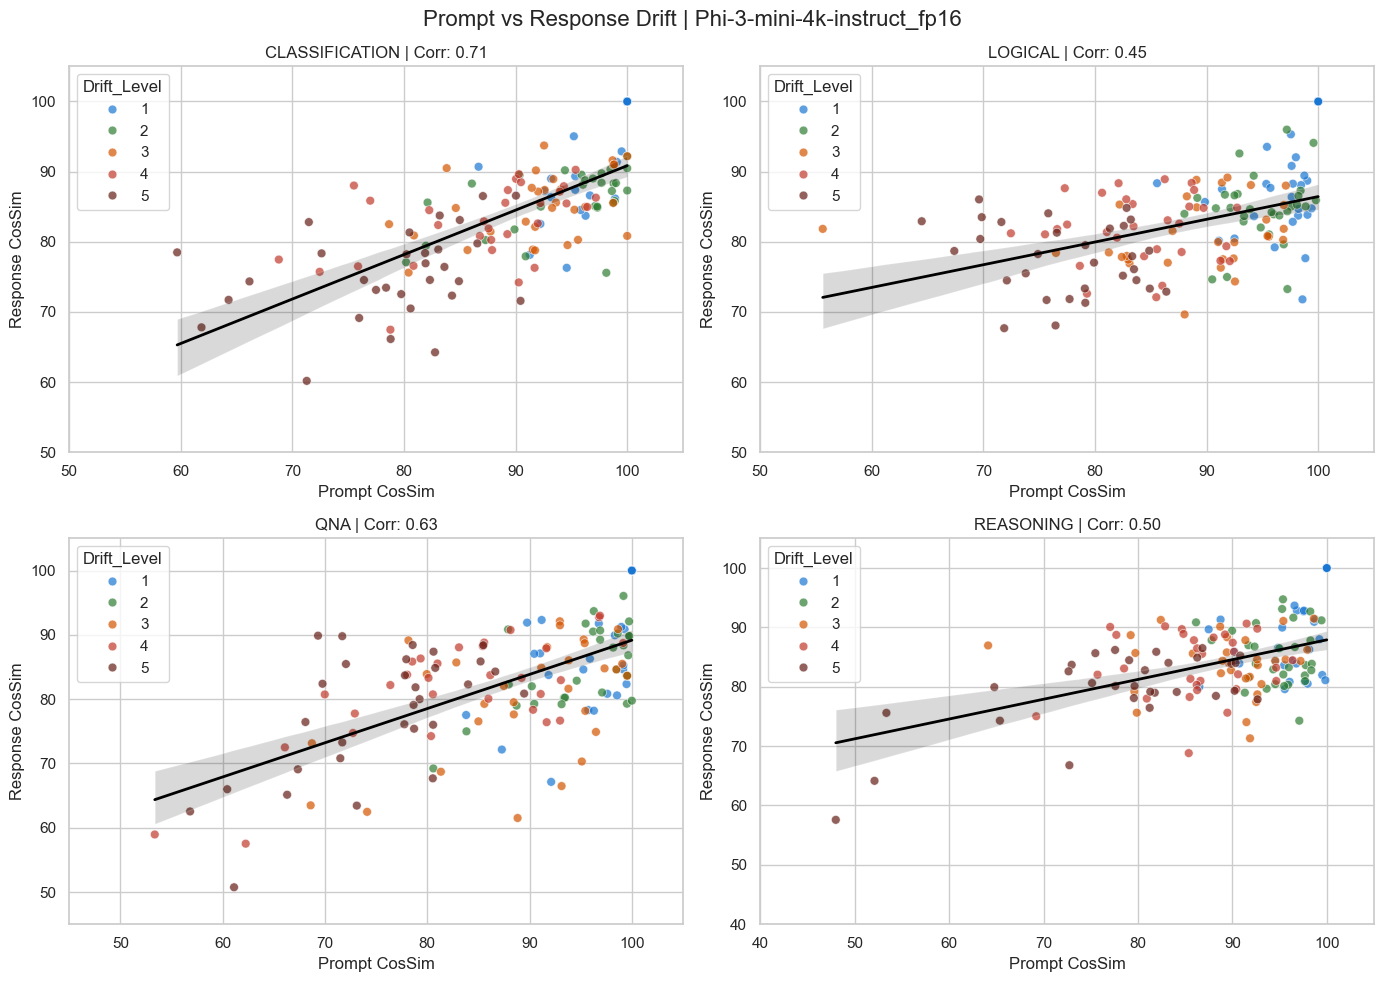

In [15]:
visualize_grid_scatter(OUTPUT_FILE2)

In [23]:
def visualize_grid_drift(comparison_csv):

    df = pd.read_csv(comparison_csv)

    resp_cols = [c for c in df.columns if c.endswith("_Resp_Overall_Drift_Mean")]
    model_quants = sorted(list(set([c.replace("_Resp_Overall_Drift_Mean", "") for c in resp_cols])))
    
    categories = sorted(df["Category"].unique())[:4]

    # Outer loop: Create a separate figure for EACH model quantization
    for model_quant in model_quants:
        
        # Create a 1x4 grid (1 row, 4 columns) 
        # Widened the figsize so the 4 plots have room to breathe side-by-side
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        axes = axes.flatten() 

        # Inner loop: Plot each category
        for i, cat in enumerate(categories):
            
            ax = axes[i]
            cat_df = df[df["Category"] == cat]

            summary = cat_df.groupby("Drift_Level").mean(numeric_only=True)

            mean_col = f"{model_quant}_Resp_Overall_Drift_Mean"

            if mean_col not in summary.columns:
                ax.set_title(f"{cat.upper()} (No Data)")
                continue

            # dynamic y scaling
            cols_to_check = [mean_col, "Prompt_Overall_Drift_Mean"]
            existing_cols = [c for c in cols_to_check if c in summary.columns]

            global_min = summary[existing_cols].min().min()
            y_floor = max(0, (global_min // 5) * 5 - 5)

            # plot prompt baseline
            if "Prompt_Overall_Drift_Mean" in summary.columns:
                ax.plot(
                    summary.index,
                    summary["Prompt_Overall_Drift_Mean"],
                    linestyle="--",
                    marker="X",
                    linewidth=2,
                    label="PROMPT"
                )

            # plot model
            ax.plot(
                summary.index,
                summary[mean_col],
                marker="o",
                label=model_quant
            )

            ax.set_title(cat.upper())
            ax.set_xlabel("Drift Level")
            
            # Only add the Y-axis label to the far-left plot
            if i == 0:
                ax.set_ylabel("Mean CosSim")
                
            ax.set_xticks([1, 2, 3, 4, 5])
            ax.set_ylim(y_floor, 105)

            ax.legend()

        # Added a slight vertical offset (y=1.05) so the title doesn't overlap the charts
        plt.suptitle(f"Drift Stability Curves | Model: {model_quant}", fontsize=16, fontweight='bold', y=1.05)
        
        plt.tight_layout()
        plt.show()

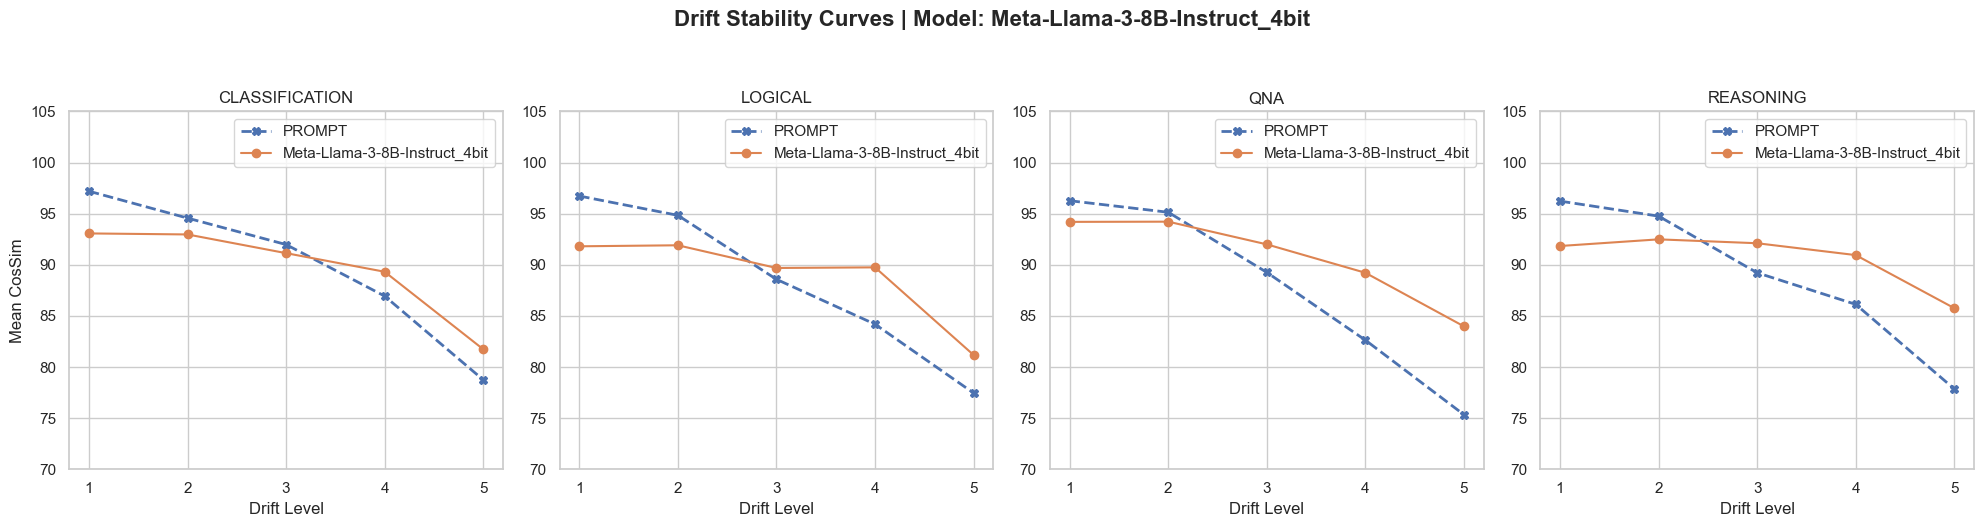

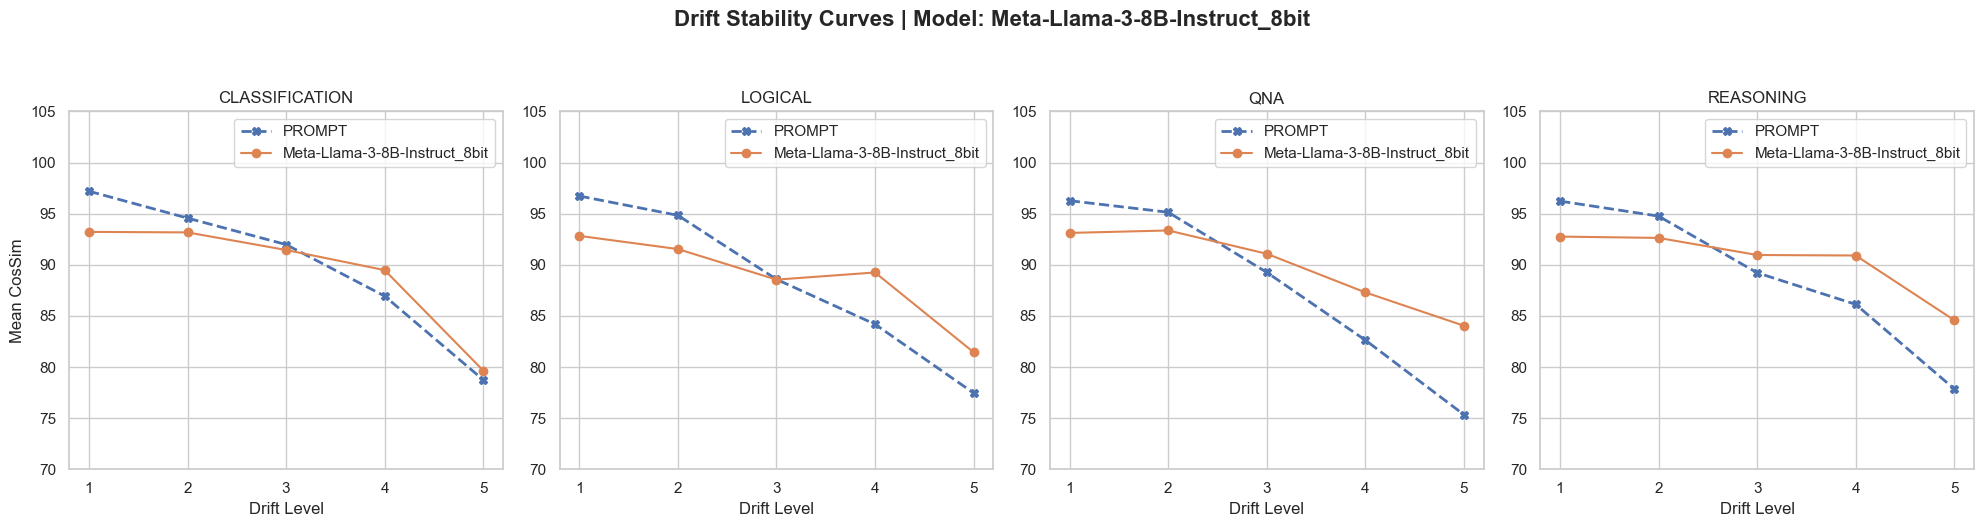

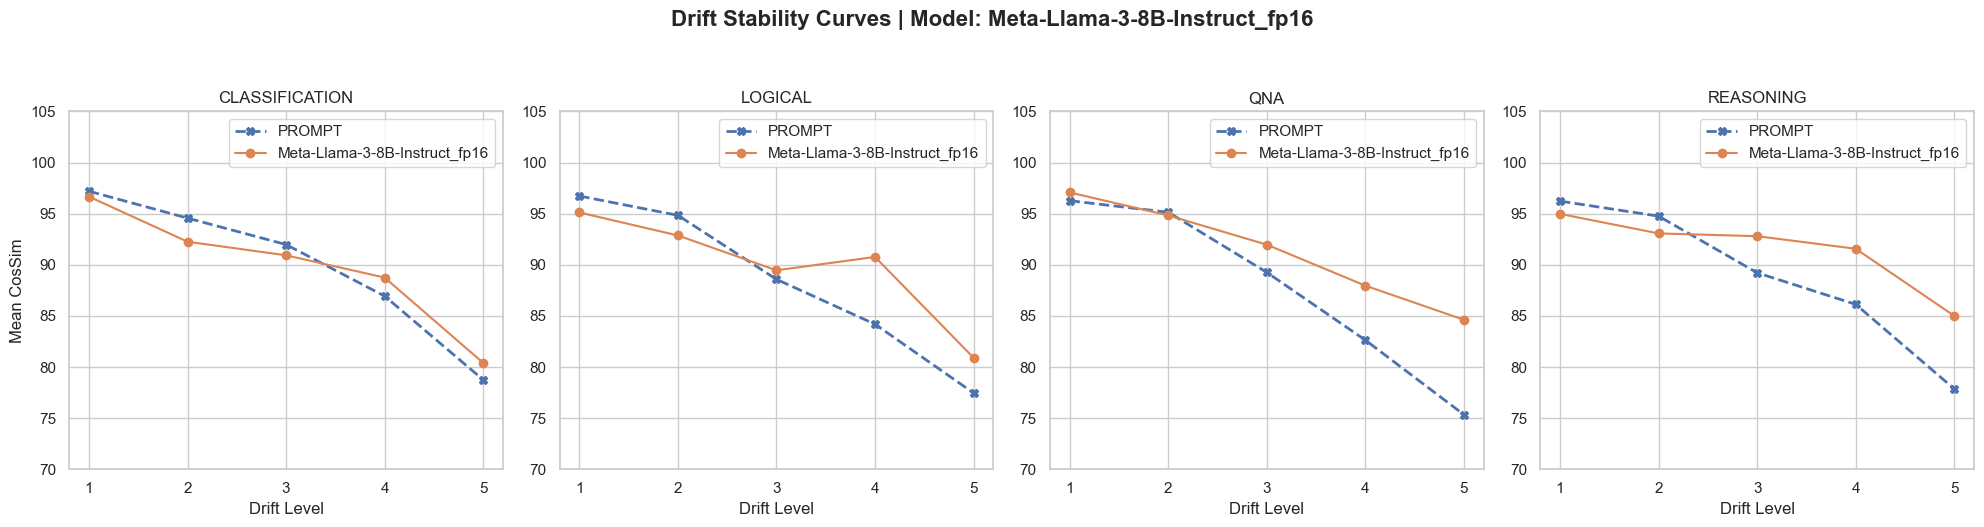

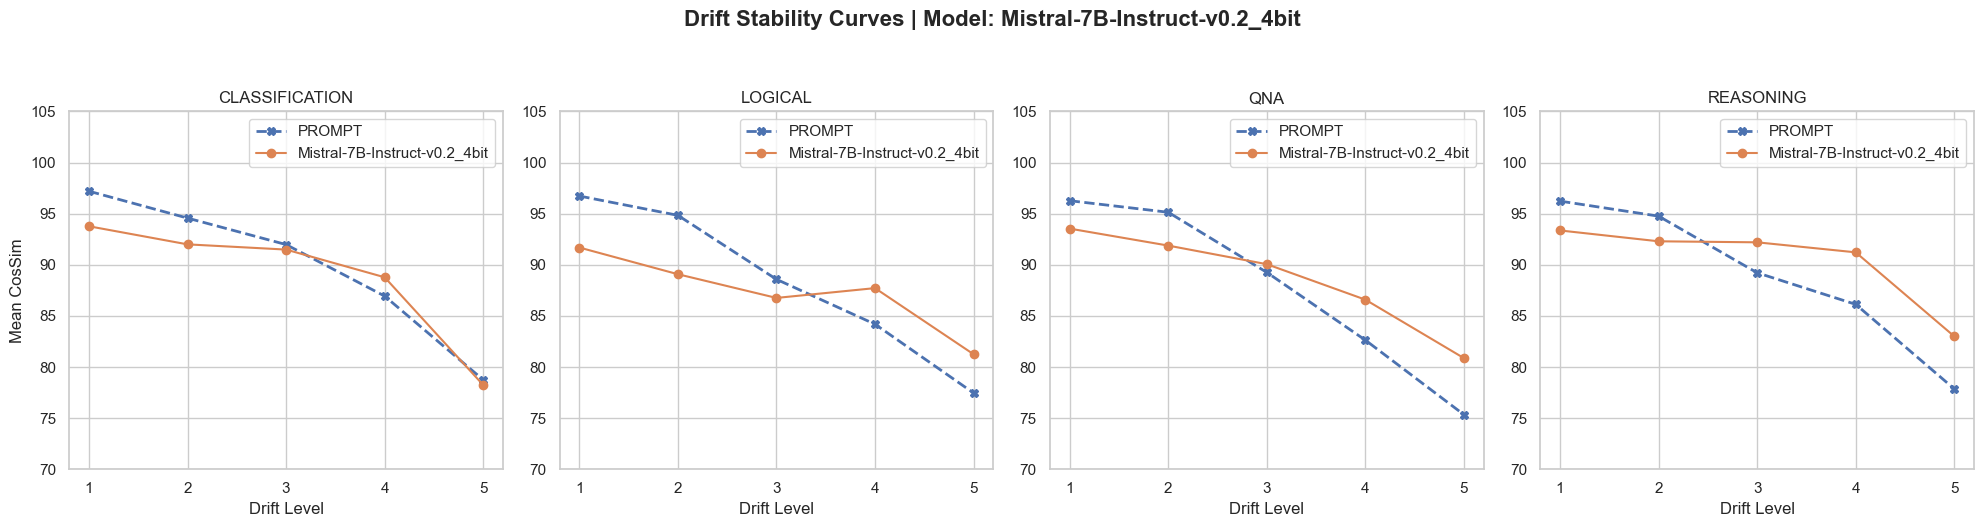

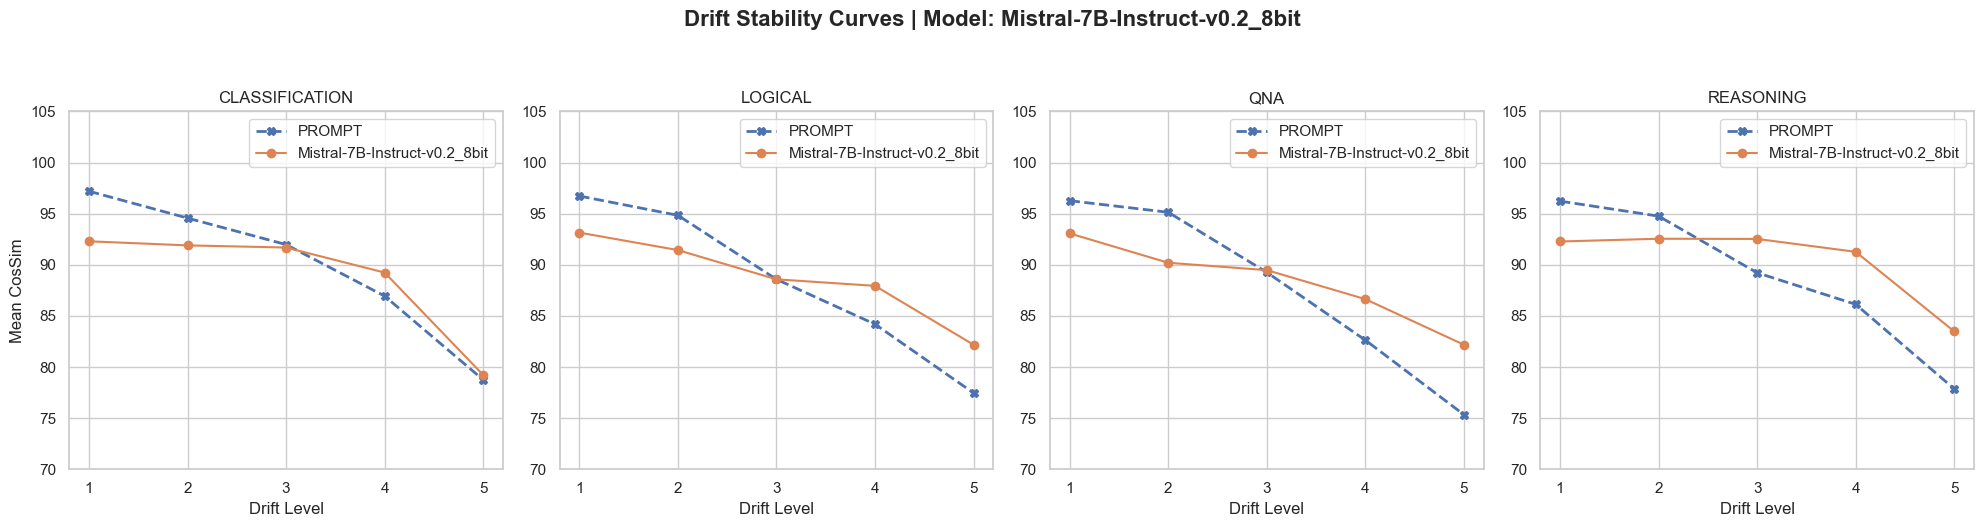

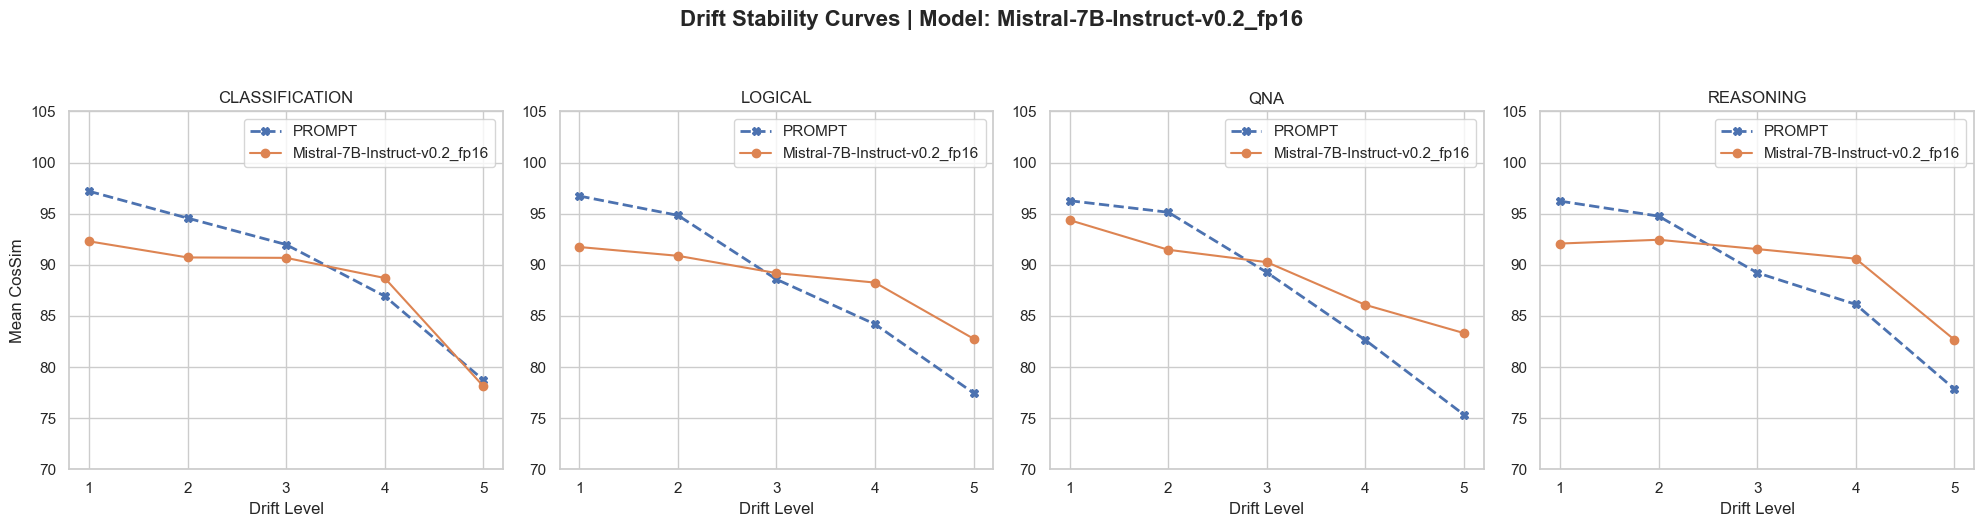

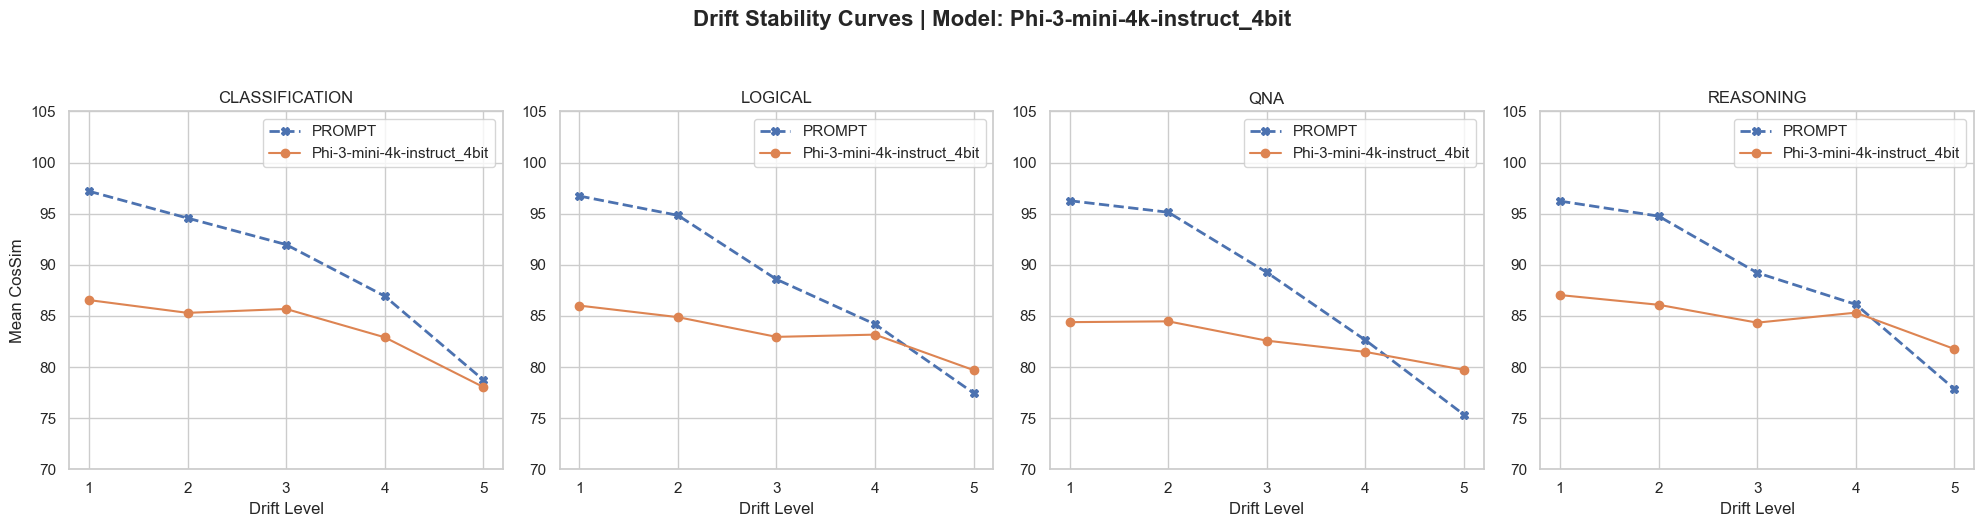

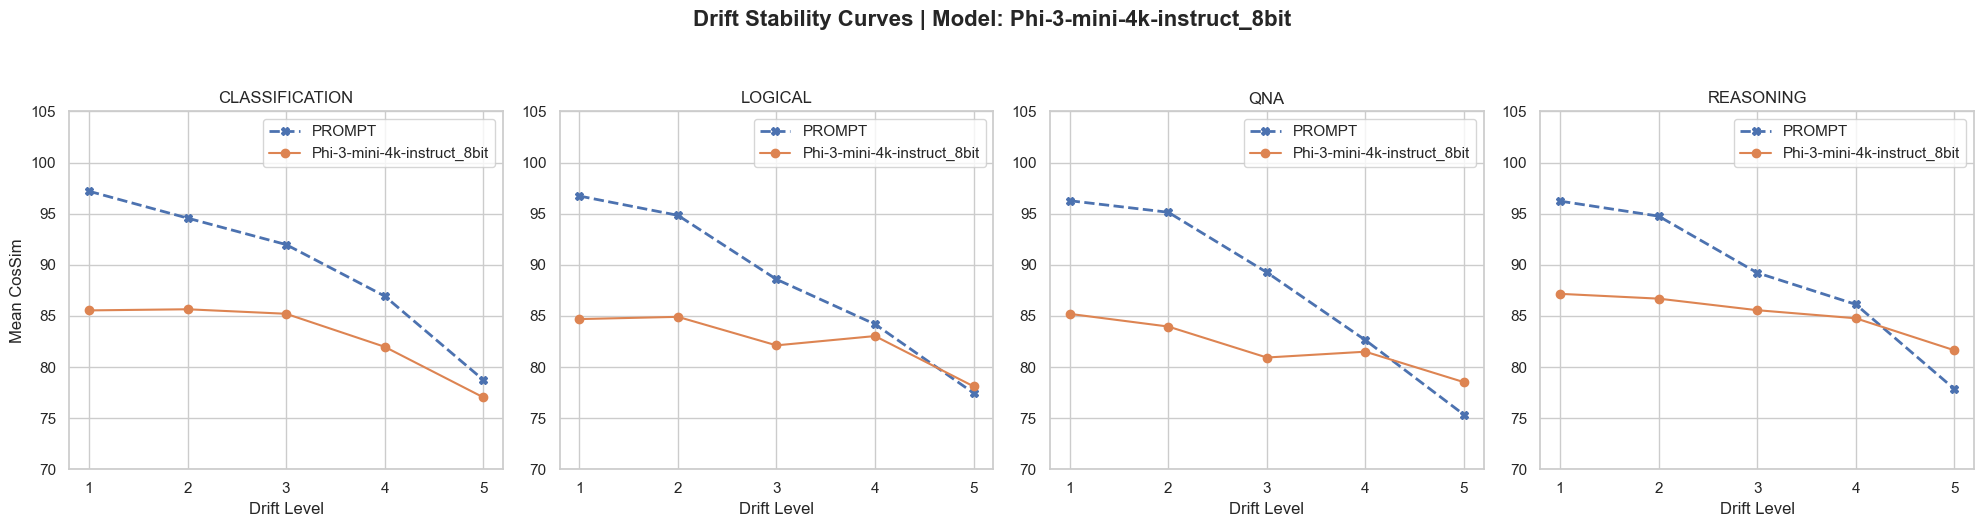

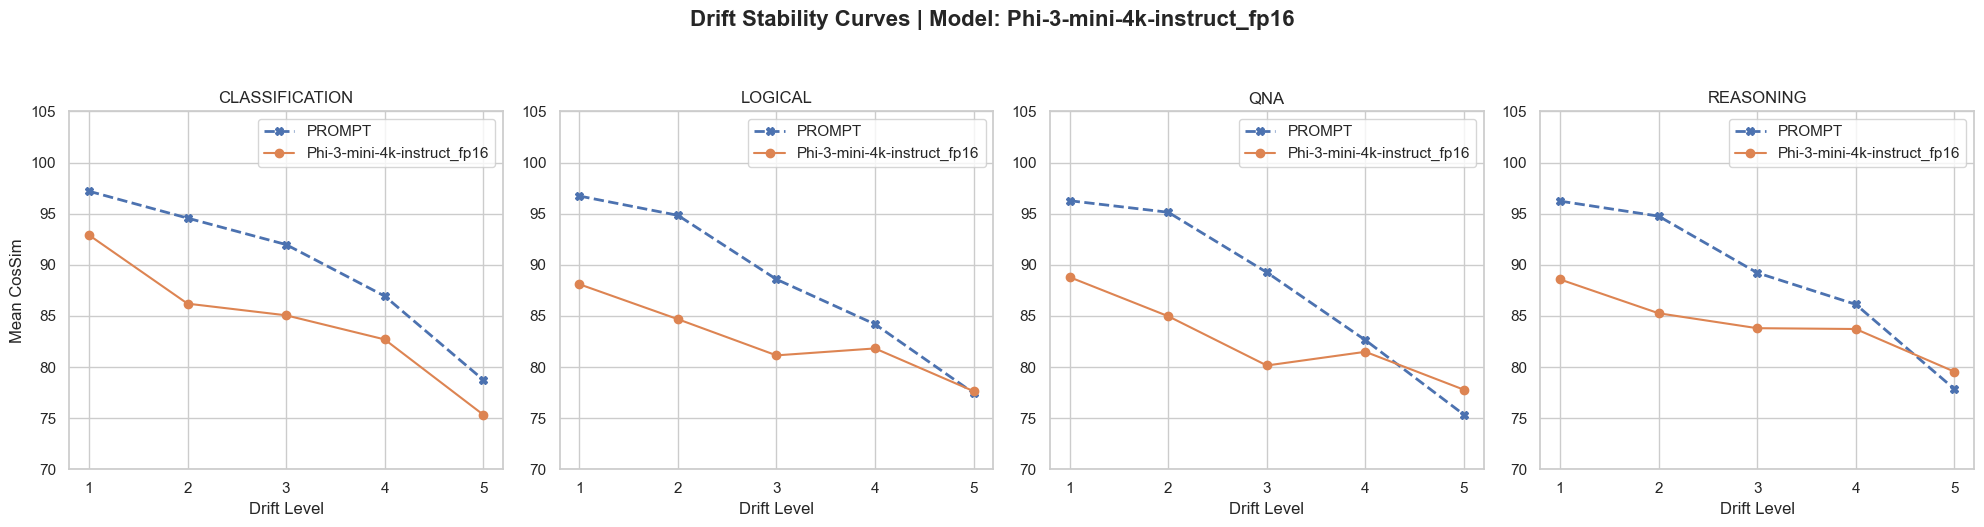

In [24]:
visualize_grid_drift(OUTPUT_FILE2)